In [88]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Datos del ejercicio
Queremos establecer el almacén de nuestra empresa en otra localización y necesitamos estimar el ritmo de las ventas, que desde la creación de la empresa ha ido en aumento, para los próximos meses, a fin de proveer el espacio que necesitaremos.


In [89]:
df=pd.read_csv('https://breathecode.herokuapp.com/asset/internal-link?id=2546&path=sales.csv')
df.head

<bound method NDFrame.head of                            date        sales
0    2022-09-03 17:10:08.079328    55.292157
1    2022-09-04 17:10:08.079328    53.803211
2    2022-09-05 17:10:08.079328    58.141693
3    2022-09-06 17:10:08.079328    64.530899
4    2022-09-07 17:10:08.079328    66.013633
..                          ...          ...
361  2023-08-30 17:10:08.079328   989.600354
362  2023-08-31 17:10:08.079328   994.987326
363  2023-09-01 17:10:08.079328   995.814415
364  2023-09-02 17:10:08.079328   997.350214
365  2023-09-03 17:10:08.079328  1000.482785

[366 rows x 2 columns]>

# limpieza y transformacion de datos

In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    366 non-null    object 
 1   sales   366 non-null    float64
dtypes: float64(1), object(1)
memory usage: 5.8+ KB


In [91]:
# Convertimos la columna 'date' a tipo datetime y la establecemos como índice
df['date'] = pd.to_datetime(df['date']).dt.normalize()
df.set_index('date', inplace=True)

In [92]:
df.tail(10)


,sales
date,
2023-08-25,971.046134
2023-08-26,977.744160
2023-08-27,980.341854
2023-08-28,986.244637
2023-08-29,989.081673
2023-08-30,989.600354
2023-08-31,994.987326
2023-09-01,995.814415
2023-09-02,997.350214


/tmp/ipykernel_1387/35774096.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df.resample("M").mean()


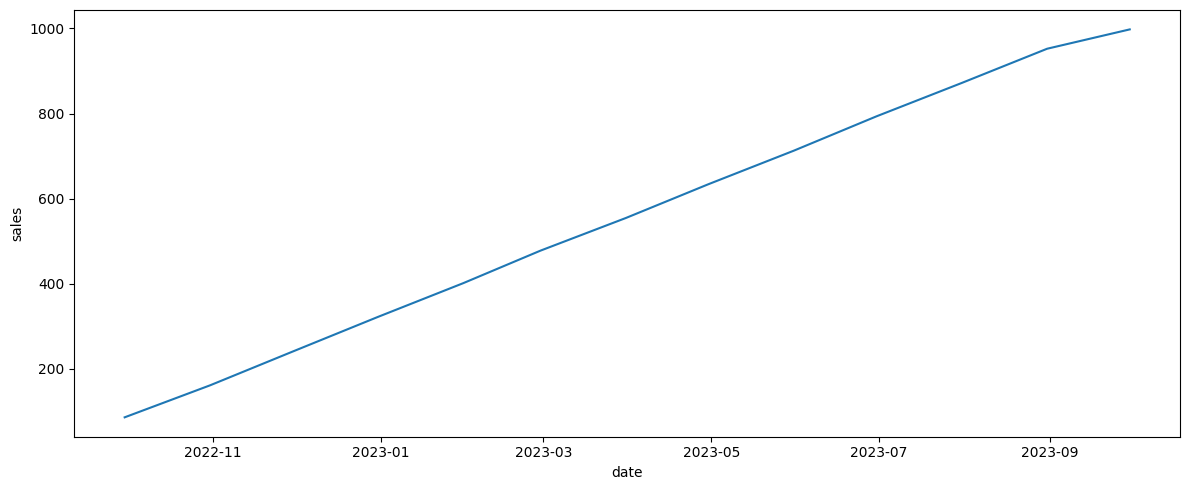

In [93]:
# Resampleamos los datos para obtener la media mensual
df_monthly = df.resample("M").mean()
# Visualizamos la serie temporal de ventas mensuales
fig, axis = plt.subplots(figsize=(12, 5))

sns.lineplot(
    data=df_monthly,
    x=df_monthly.index,
    y="sales",
    ax=axis
)
plt.tight_layout()
plt.show()

In [94]:
# verificamos que no hay valores faltantes
df.isna().sum()

sales    0
dtype: int64

In [95]:
# Forzamos la frecuencia diaria en el índice de fechas
df = df.asfreq('D')
# Verificamos nuevamente los valores faltantes
df.isna().sum()

sales    0
dtype: int64

# Graficamos

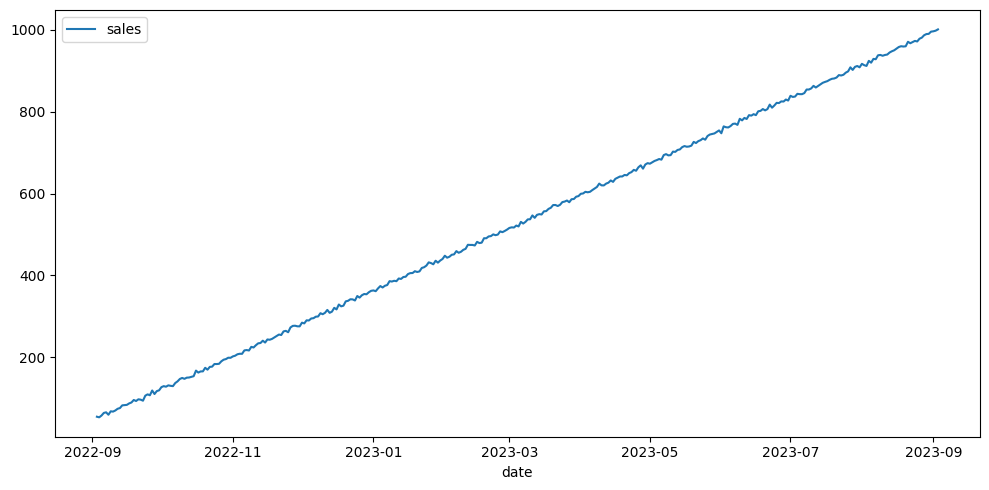

In [96]:
fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = df)

plt.tight_layout()

plt.show()

## Tensor
Tenemos que el tensor es: " la unidad de tiempo mínima para la cual hay datos. Puede ser cada segundo, minuto, hora, día, semana, mes..." en este caso es una serie que presenta datos cada dia.

## Tendencia

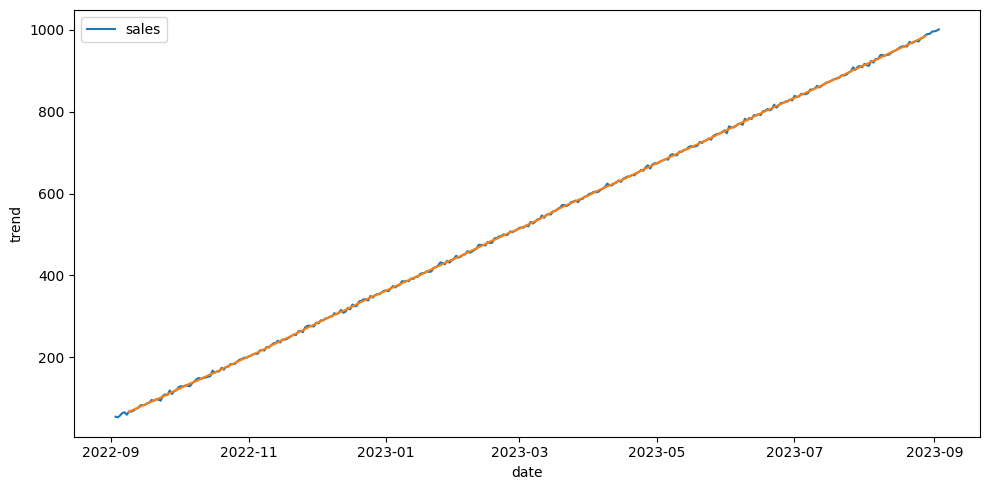

In [97]:
decomposition = seasonal_decompose(df, period = 12)
decomposition
trend = decomposition.trend

fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = df)
sns.lineplot(data = trend)

plt.tight_layout()

plt.show()

podemos ver como ya se intuia en la primera grafica que presenta una tendencia alsista

## Estacionalidad

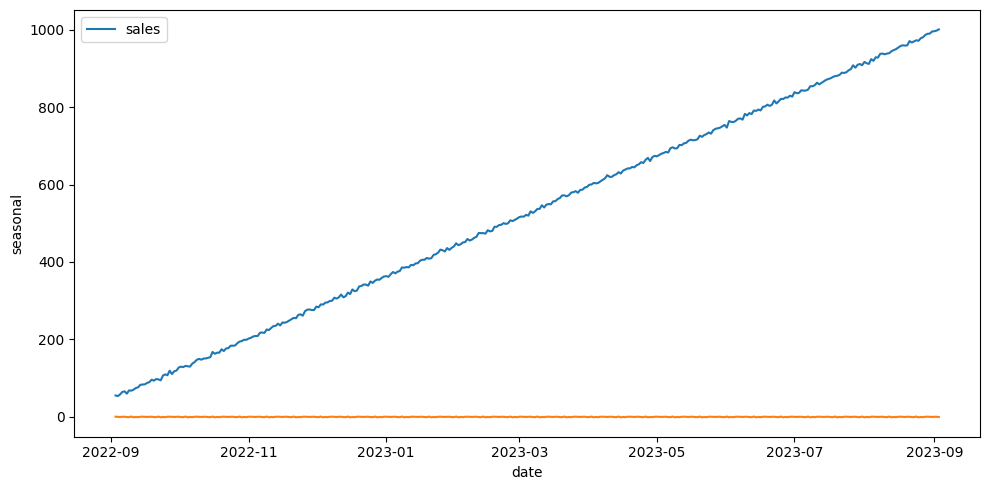

In [98]:
seasonal = decomposition.seasonal

fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = df)
sns.lineplot(data = seasonal)

plt.tight_layout()

plt.show()

Para evaluar la estacionalidad de la serie temporal podemos aplicar la llamada Prueba de Dickey-Fuller (Dickey-Fuller test), que es un contraste de hipótesis en el que la hipótesis nula es que la serie es estacionaria, y la alternativa, que es no estacionaria

In [99]:
def test_stationarity(timeseries):
    print("Resultados de la prueba de Dickey-Fuller:")
    dftest = adfuller(timeseries, autolag = "AIC")
    dfoutput = pd.Series(dftest[0:4], index = ["Test Statistic", "p-value", "#Lags Used", "Number of Observations Used"])
    for key,value in dftest[4].items():
        dfoutput["Critical Value (%s)"%key] = value
    return dfoutput

test_stationarity(df)

Resultados de la prueba de Dickey-Fuller:


Test Statistic                   0.545414
p-value                          0.986190
#Lags Used                      13.000000
Number of Observations Used    352.000000
Critical Value (1%)             -3.449065
Critical Value (5%)             -2.869786
Critical Value (10%)            -2.571163
dtype: float64


Aquí podemos ver que el p-value es mayor a 0.05, esto significa que nuestra hipótesis nula será rechazada y tomaremos esta serie como no estacionaria, igualmente ya en la grafica se podia ir intuyendo ya que al analizarla vemos que no hay patrones estacionales visibles dentro de una tendencia muy marcada

## Variabilidad

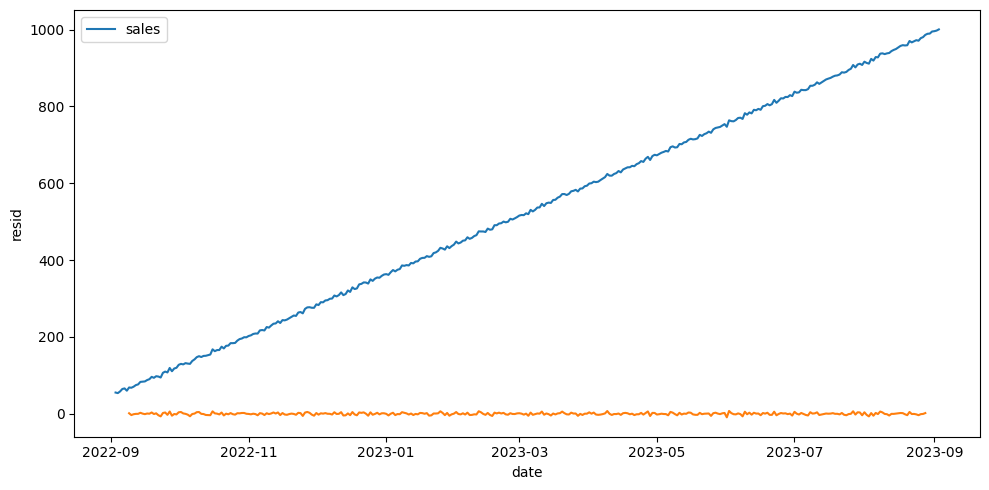

In [100]:
residual = decomposition.resid

fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = df)
sns.lineplot(data = residual)

plt.tight_layout()

plt.show()

Las fluctuaciones alrededor de la tendencia son pequeñas y bastante constantes en el tiempo. No se observa que la amplitud del ruido aumente o disminuya conforme crece el nivel de la serie

## Autocorrelación

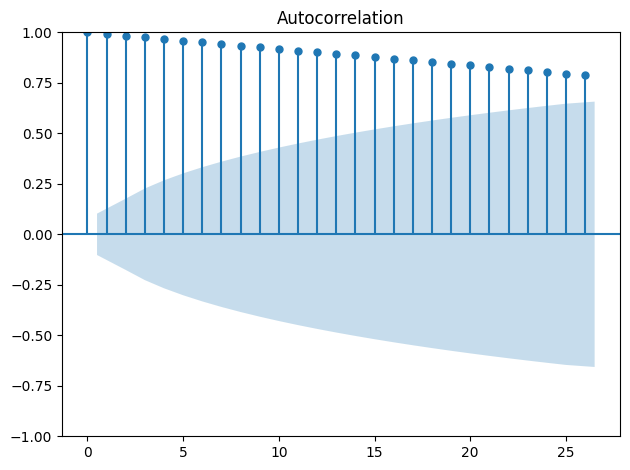

In [101]:
plot_acf(df)

plt.tight_layout()

plt.show()

Se aprecia una alta correlación entre los puntos y sus copias retrasadas, que disminuye a lo largo del tiempo.

# Entrenamiento modelo ARIMA

In [102]:
# convertimos la serie temporal en estacionaria aplicando la diferenciación
df_stationary = df.diff().dropna()

test_stationarity(df_stationary)

Resultados de la prueba de Dickey-Fuller:


Test Statistic                -9.430263e+00
p-value                        5.212954e-16
#Lags Used                     1.200000e+01
Number of Observations Used    3.520000e+02
Critical Value (1%)           -3.449065e+00
Critical Value (5%)           -2.869786e+00
Critical Value (10%)          -2.571163e+00
dtype: float64

In [120]:
model = auto_arima(df_stationary, seasonal = True, trace = True, m = 12)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=1847.119, Time=1.58 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=2096.542, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=1972.854, Time=0.42 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=inf, Time=0.76 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=2209.657, Time=0.01 sec
 ARIMA(2,0,2)(0,0,1)[12] intercept   : AIC=1845.127, Time=0.73 sec
 ARIMA(2,0,2)(0,0,0)[12] intercept   : AIC=1843.049, Time=0.44 sec
 ARIMA(2,0,2)(1,0,0)[12] intercept   : AIC=1845.092, Time=0.90 sec
 ARIMA(1,0,2)(0,0,0)[12] intercept   : AIC=1843.587, Time=0.15 sec
 ARIMA(2,0,1)(0,0,0)[12] intercept   : AIC=1841.533, Time=0.50 sec
 ARIMA(2,0,1)(1,0,0)[12] intercept   : AIC=1843.436, Time=1.17 sec
 ARIMA(2,0,1)(0,0,1)[12] intercept   : AIC=1843.433, Time=0.98 sec
 ARIMA(2,0,1)(1,0,1)[12] intercept   : AIC=inf, Time=1.27 sec
 ARIMA(1,0,1)(0,0,0)[12] intercept   : AIC=1839.553, Time=0.21 sec
 ARIMA(1,0,1)(1,0,0)[12] inte

In [121]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  365
Model:               SARIMAX(1, 0, 1)   Log Likelihood                -915.776
Date:                Fri, 09 Jan 2026   AIC                           1839.553
Time:                        20:03:37   BIC                           1855.152
Sample:                    09-04-2022   HQIC                          1845.752
                         - 09-03-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      2.8110      0.134     21.055      0.000       2.549       3.073
ar.L1         -0.0821      0.052     -1.592      0.111      -0.183       0.019
ma.L1         -0.9413      0.020    -47.701      0.000      -0.980      -0.903
sigma2         8.7903      0.688     12.777      0.000       7.442      10.139
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 0.76
Prob(Q):                              1.00   Prob(JB):                         0.68
Heteroskedasticity (H):               0.90   Skew:                             0.07
Prob(H) (two-sided):                  0.58   Kurtosis:                         2.82
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [122]:
forecast = model.predict(10)
forecast

2023-09-04    1.675366
2023-09-05    2.673520
2023-09-06    2.591621
2023-09-07    2.598341
2023-09-08    2.597789
2023-09-09    2.597834
2023-09-10    2.597831
2023-09-11    2.597831
2023-09-12    2.597831
2023-09-13    2.597831
Freq: D, dtype: float64

Estos datos que predecimos no nos dicen nada, ya que son datos estacionarios por lo procedemos a aplicar el  SARIMAX

In [124]:
model = SARIMAX(df['sales'], order=(0,1,1), seasonal_order=(1,1,1,7))
result = model.fit()
forecast = result.forecast(steps=10)
forecast

2023-09-04    1002.840564
2023-09-05    1005.123954
2023-09-06    1007.160633
2023-09-07    1009.835966
2023-09-08    1011.527159
2023-09-09    1015.711292
2023-09-10    1018.340044
2023-09-11    1020.841823
2023-09-12    1023.056679
2023-09-13    1025.281266
Freq: D, Name: predicted_mean, dtype: float64

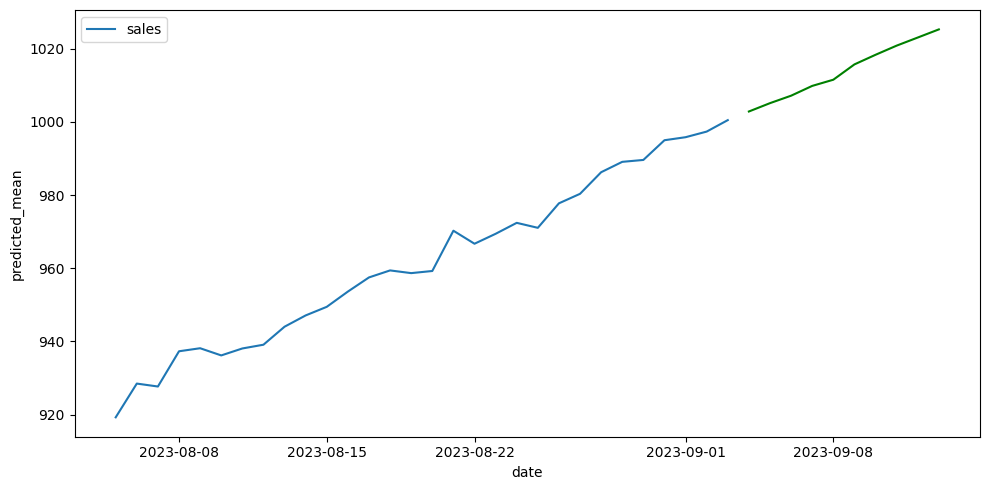

In [126]:
fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = df.tail(30))
sns.lineplot(data = forecast, c = "green")

plt.tight_layout()

plt.show()

Para este caso debido a que presentaba una variabilidad entre sus datos bastante baja y el cambio diario entre estos diario era demasiado bajo, se opto porque el SARIMX tuviera un periodo de estacionalidad semanal, ya que de lo contrario, al presentar tan baja estacionalidad los valores predichos todos eran iguales.